# Meituan algorithm playground

Edit the **Settings** cell and run the notebook to compare dispatch algorithms on
the same Meituan jobs. Start with the default 120-second slice, then change the
day, dataset, pooling window, shadow, or policy. Optional sections run a small
parameter sweep and export the results.

All policy, reward, matching, and LP calculations come from the existing `ddp`
modules. This notebook only selects data, passes parameters, and displays results.
It runs locally; it does not submit GRID jobs.

## Setup

Use a Jupyter kernel with the project dependencies installed (the project's
`.venv/bin/python` is suitable here). For a new environment, install the project
with `pip install -e .` and add `ipykernel` plus your preferred Jupyter frontend.
The cell below locates the repository from either its root or `notebooks/` and
imports the current source checkout. Restart the kernel after changing package code.

In [1]:
from pathlib import Path
from copy import deepcopy
from time import perf_counter
from datetime import datetime, timezone
import hashlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT_OVERRIDE = None  # Optional absolute Path if launching outside the repository.
if ROOT_OVERRIDE is not None:
    ROOT = Path(ROOT_OVERRIDE).expanduser().resolve()
else:
    ROOT = next(
        (p for p in (Path.cwd(), *Path.cwd().parents)
         if (p / "src/ddp/scripts/run.py").is_file()),
        None,
    )
if ROOT is None or not (ROOT / "src/ddp/scripts/run.py").is_file():
    raise FileNotFoundError("Set ROOT_OVERRIDE to the ddp_pkg_release directory.")
sys.path.insert(0, str(ROOT / "src"))

import ddp
from ddp.scripts.csv_loader import load_jobs_from_csv
from ddp.scripts.run import run_instance, load_average_duals, make_reward_fn
from ddp.mappings.h3_pairs import make_mapping, job_mapping

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False})
print("Project:", ROOT)
print("Python:", sys.executable)
print("ddp:", ddp.__file__)

Project: /Users/mer2262/Documents/Columbia/Research/Dynamic Delivery Pooling/ddp_pkg_release
Python: /Users/mer2262/Documents/Columbia/Research/Dynamic Delivery Pooling/ddp_pkg_release/.venv/bin/python
ddp: /Users/mer2262/Documents/Columbia/Research/Dynamic Delivery Pooling/ddp_pkg_release/src/ddp/__init__.py


## Settings

`d`, `tau_s`, and the data-selection interval are in **seconds**.
For ordinary policies, the effective shadow is
$s_i = \gamma\,s_i^{\mathrm{base}} + \tau$.
For PB, $s_i^{\mathrm{base}}=L_i/2$: **gamma = 0.3 means a coefficient of 0.15 on distance**.
`tau` is an additive shadow offset, in the model's distance units; it is not a time window.

| Setting | Choices / meaning |
|---|---|
| `SCOPE`, `DAY` | `"city"` or the existing `"area6"` snapshots; day indices 0–7 |
| `JOBS_CSV` | Optional custom snapshot path, overriding `SCOPE` / `DAY` |
| `START_S`, `DURATION_S` | Interval relative to the first valid arrival in the full snapshot; `DURATION_S=None` selects the rest of the snapshot |
| `shadows` | `naive` (zero base), `pb` (potential), `hd` (hindsight LP duals), `ad` (precomputed historical duals) |
| `dispatches` | `greedy`, `greedyx`, `greedy+`, `batch`, `rbatch`, `batch+`, `rbatch+`, `batch2`, `rbatch2` |
| `gamma`, `tau` | Ordinary shadow scaling and additive offset; explicit values avoid policy-dependent defaults |
| `gamma_plus`, `tau_plus` | Separate controls for **batch+ and rbatch+**; these subtract only the later-arriving job's shadow. **greedy+ still uses gamma/tau.** |
| `tau_s` | Matching tick interval for `batch2` / `rbatch2`; keep it no larger than `d` |
| `seed`, `tie_breaker` | Greedy tie resolution: `random` or `distance`; this does not resample Meituan jobs |
| `with_opt` | Also compute integral offline OPT; the fractional LP benchmark is always computed |

Use `pb` + `rbatch` for the augmented rolling-batching gamma experiment.
`naive` has zero effective shadow only when `tau=0` (and `tau_plus=0` for batch+/rbatch+).
HD uses the evaluated jobs themselves and is a hindsight reference, not a historical predictor.

In [2]:
SCOPE = "city"
DAY = 0
JOBS_CSV = None
TIMESTAMP_COLUMN = "platform_order_time"  # Or "order_push_time".
START_S = 0.0
DURATION_S = 120.0  # Set None for the remainder of the full snapshot.

RUN = dict(
    d=60.0,
    shadows=["naive", "pb"],
    dispatches=["greedy+", "batch", "rbatch"],
    gamma=0.3,
    tau=0.0,
    gamma_plus=1.0,
    tau_plus=0.0,
    tau_s=30.0,
    seed=0,
    tie_breaker="distance",
    with_opt=False,
)

## Load and inspect the jobs

The package loader sorts by arrival time, breaks timestamp ties by CSV row order,
and normalizes time to the first valid arrival. It skips malformed rows.
`full_job_index` below refers to this **loaded ordering**, not the CSV's exported
index. The interval includes all jobs with `START_S <= arrival < START_S + DURATION_S`.
Original normalized timestamps are retained, including the phase of periodic ticks.

A time slice preserves all arrivals within the interval, but excludes earlier and
later jobs. It therefore has boundary effects and is a testing instance, not a
full-day performance estimate. Selecting Area 6 also changes the matching market.
For full-day experiments use `START_S=0`, `DURATION_S=None`.

The package uses Euclidean distances on the stored coordinates. Savings and
lengths below are in those **coordinate units**, not kilometers or travel time.

In [3]:
if SCOPE not in {"city", "area6"} or DAY not in range(8):
    raise ValueError("Choose SCOPE='city'/'area6' and DAY in 0..7.")
if not np.isfinite(START_S) or START_S < 0:
    raise ValueError("START_S must be finite and nonnegative.")
if DURATION_S is not None and (not np.isfinite(DURATION_S) or DURATION_S <= 0):
    raise ValueError("DURATION_S must be positive, or None.")
csv_path = (Path(JOBS_CSV).expanduser() if JOBS_CSV is not None else
            ROOT / "data" / f"meituan_{SCOPE}_lunchtime_plat10301330_day{DAY}.csv")
if not csv_path.is_absolute():
    csv_path = ROOT / csv_path
csv_path = csv_path.resolve()
raw_frame = pd.read_csv(csv_path)
all_jobs = load_jobs_from_csv(csv_path, timestamp_column=TIMESTAMP_COLUMN)
if not all_jobs:
    raise ValueError("No valid jobs loaded.")
all_times = np.array([job.timestamp for job in all_jobs])
all_coordinates = np.array([(*job.origin, *job.dest) for job in all_jobs])
if not np.isfinite(all_coordinates).all() or not np.isfinite(all_times).all():
    raise ValueError("Non-finite job coordinates or timestamps.")
end_s = np.inf if DURATION_S is None else START_S + DURATION_S
selected_indices = np.flatnonzero((all_times >= START_S) & (all_times < end_s))
jobs = [all_jobs[i] for i in selected_indices]
if len(jobs) < 2:
    raise ValueError("Select an interval containing at least two jobs.")
job_frame = pd.DataFrame({
    "job_index": np.arange(len(jobs)),
    "full_job_index": selected_indices,
    "arrival_s": [j.timestamp for j in jobs],
    "origin_lat": [j.origin[0] for j in jobs],
    "origin_lng": [j.origin[1] for j in jobs],
    "dest_lat": [j.dest[0] for j in jobs],
    "dest_lng": [j.dest[1] for j in jobs],
    "direct_length": [j.length for j in jobs],
})
source_info = dict(
    jobs_csv=str(csv_path), jobs_csv_sha256=hashlib.sha256(csv_path.read_bytes()).hexdigest(),
    timestamp_column=TIMESTAMP_COLUMN, start_s=START_S, duration_s=DURATION_S,
    n_full_snapshot=len(all_jobs), n_selected=len(jobs),
)
print(f"{csv_path.name}: {len(raw_frame):,} CSV rows; {len(all_jobs):,} loaded; "
      f"{len(raw_frame) - len(all_jobs):,} skipped; {len(jobs):,} selected.")
print(f"Selected arrivals: {job_frame.arrival_s.min():g}–{job_frame.arrival_s.max():g} "
      "seconds after the first valid snapshot arrival.")
display(job_frame.head())

meituan_city_lunchtime_plat10301330_day0.csv: 22,535 CSV rows; 22,535 loaded; 0 skipped; 133 selected.
Selected arrivals: 0–117 seconds after the first valid snapshot arrival.


,job_index,full_job_index,arrival_s,origin_lat,origin_lng,dest_lat,dest_lng,direct_length
0,0,0,0.0,46.052810,174.946400,46.062727,174.939043,0.012348
1,1,1,0.0,45.879711,174.547190,45.879063,174.546151,0.001225
2,2,2,3.0,45.898786,174.565946,45.902213,174.544656,0.021564
3,3,3,4.0,45.866698,174.606413,45.877599,174.603587,0.011261
4,4,4,5.0,45.891251,174.576113,45.908985,174.572496,0.018099


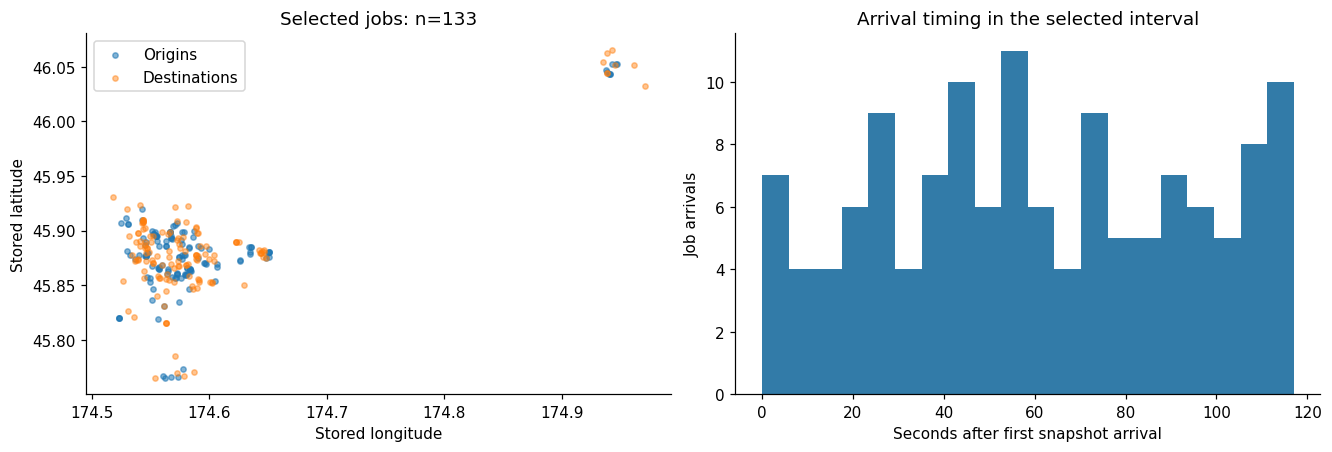

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].scatter(job_frame.origin_lng, job_frame.origin_lat,
                s=12, alpha=0.55, label="Origins")
axes[0].scatter(job_frame.dest_lng, job_frame.dest_lat,
                s=12, alpha=0.45, label="Destinations")
axes[0].set(xlabel="Stored longitude", ylabel="Stored latitude",
            title=f"Selected jobs: n={len(jobs):,}")
axes[0].legend()
axes[1].hist(job_frame.arrival_s, bins=min(20, len(jobs)), color="#327ba8")
axes[1].set(xlabel="Seconds after first snapshot arrival", ylabel="Job arrivals",
            title="Arrival timing in the selected interval")
plt.show()

## Optional average-dual (AD) input

Leave `AD_FILES` empty unless using `ad`. Supply a table for **each pooling window**
being tested. Use historical tables built from the other days, with the same target
day, city/Area 6 scope, timestamp convention, and coordinate model as this instance.
The notebook does not compute new historical duals.

Job-indexed tables must cover the **full loaded snapshot** in its sorted ordering;
the helper slices them with `selected_indices`. For enriched tables, coordinates
and timestamps are checked against the snapshot before slicing. A two-column
`job_index,mean_dual` table has no identity metadata, so its provenance must be
verified separately. Type-indexed tables use the existing H3 pair mapper at
`AD_H3_RESOLUTION`; all selected types must be covered (no silent fallback).

Example for the existing day-0, d=10, resolution-8 export:
`AD_FILES = {10.0: ROOT / "data/average_duals_v0/meituan_ad_day0_d10_res8_full.csv"}`.
Set the run's `d=10` and add `ad` to `shadows` to try it.

In [5]:
AD_FILES = {}  # {pooling_window_seconds: Path/to/the_matching_table.csv}
AD_H3_RESOLUTION = 8

## Evaluation helper

This thin wrapper validates settings and AD alignment, then calls
`ddp.scripts.run.run_instance`. One call shares its LP/OPT computation across the
chosen shadows and dispatchers. Separate calls (including sweep points) recompute
the LP; large citywide runs can be expensive. There is no automatic time limit;
use the kernel's interrupt action to stop a local experiment.

In [6]:
VALID_SHADOWS = {"naive", "pb", "hd", "ad"}
VALID_DISPATCHES = {"greedy", "greedyx", "greedy+", "batch", "rbatch",
                    "batch+", "rbatch+", "batch2", "rbatch2"}

def ad_for_window(d):
    if d not in AD_FILES:
        raise ValueError(f"Add an AD_FILES entry for d={d}; use the matching historical table.")
    path = Path(AD_FILES[d]).expanduser()
    path = path if path.is_absolute() else ROOT / path
    table = load_average_duals(str(path))
    mapper = None
    if table.by_job is not None:
        values = np.asarray(table.by_job, dtype=float)
        if values.shape != (len(all_jobs),) or not np.isfinite(values).all():
            raise ValueError("AD values must be finite and cover the full loaded snapshot.")
        if path.suffix.lower() == ".csv":
            metadata = pd.read_csv(path)
            metadata.columns = metadata.columns.str.strip().str.lower()
            index_col = "job_index" if "job_index" in metadata else "index"
            if metadata[index_col].duplicated().any():
                raise ValueError("Duplicate AD job indices.")
            metadata = metadata.sort_values(index_col)
            fields = ["sender_lat", "sender_lng", "recipient_lat", "recipient_lng"]
            if set(fields).issubset(metadata.columns):
                if not np.allclose(metadata[fields].to_numpy(float), all_coordinates,
                                   rtol=0, atol=1e-9):
                    raise ValueError("AD coordinates do not match this snapshot's job ordering.")
            if "timestamp" in metadata:
                if not np.allclose(metadata.timestamp.to_numpy(float), all_times,
                                   rtol=0, atol=1e-6):
                    raise ValueError("AD timestamps do not match the selected timestamp convention.")
        payload = values[selected_indices]
    else:
        h3_mapper = make_mapping(AD_H3_RESOLUTION)
        mapper = lambda job: job_mapping(job, mapper=h3_mapper)
        if not np.isfinite(list(table.by_type.values())).all():
            raise ValueError("AD type values must be finite.")
        missing = [i for i, job in enumerate(jobs)
                   if str(mapper(job)) not in table.by_type]
        if missing:
            raise ValueError(f"AD table misses {len(missing)} selected jobs; check the H3 resolution.")
        payload = table
    provenance = dict(path=str(path.resolve()), sha256=hashlib.sha256(path.read_bytes()).hexdigest(),
                      format=table.format, h3_resolution=AD_H3_RESOLUTION if mapper else None)
    return payload, mapper, provenance


def run_experiment(**settings):
    options = deepcopy(settings)
    for key, valid in (("shadows", VALID_SHADOWS), ("dispatches", VALID_DISPATCHES)):
        values = options.get(key)
        if isinstance(values, str) or not values or set(values) - valid:
            raise ValueError(f"{key} must be a nonempty list chosen from {sorted(valid)}.")
        if len(set(values)) != len(values):
            raise ValueError(f"Remove duplicate entries from {key}.")
    for key in ("d", "gamma", "tau", "gamma_plus", "tau_plus", "tau_s"):
        value = options[key]
        if not np.isscalar(value) or not np.isfinite(value):
            raise ValueError(f"{key} must be an explicit finite scalar.")
    if options["d"] < 0:
        raise ValueError("d must be nonnegative.")
    if options["tie_breaker"] not in {"random", "distance"}:
        raise ValueError("tie_breaker must be 'random' or 'distance'.")
    if set(options["dispatches"]) & {"batch2", "rbatch2"}:
        if not 0 < options["tau_s"] <= options["d"]:
            raise ValueError("Use 0 < tau_s <= d so periodic ticks respect the LP's waiting horizon.")
    ad_payload = ad_mapper = ad_provenance = None
    if "ad" in options["shadows"]:
        ad_payload, ad_mapper, ad_provenance = ad_for_window(options["d"])
    started = perf_counter()
    out = run_instance(
        jobs, **options, reward_type="pooling", return_details=True,
        ad_duals=ad_payload, ad_mapper=ad_mapper,
    )
    out["wall_time_s"] = perf_counter() - started
    out["settings"] = options
    out["source"] = dict(source_info)
    out["ad_source"] = ad_provenance
    frame = pd.DataFrame(out["rows"])
    frame["lp_upper"] = out["lp_total"]
    frame["opt_total"] = out["opt_total"]
    frame["savings_per_job"] = frame.savings / len(jobs)
    frame["savings_pct_direct_distance"] = 100 * frame.savings / job_frame.direct_length.sum()
    for _, row in frame.iterrows():
        if 2 * row.pairs + row.solos != len(jobs):
            raise AssertionError("Dispatch accounting does not reconcile.")
    out["summary"] = frame
    return out

## Run the selected comparison

Change `RUN`, then rerun this section. After changing the input file or time slice,
rerun from the data-loading section so jobs and AD alignment are refreshed.
`pooled_pct` is the percentage of **jobs** in pairs. `savings` is total distance
saved; `ratio_lp` is savings divided by the fractional LP upper bound.
`time_s` measures policy execution only; LP/OPT setup is reported separately.

In [7]:
result = run_experiment(**RUN)
summary = result["summary"]
display(summary.sort_values("savings", ascending=False).reset_index(drop=True))
print(f"LP: {result['lp_time']:.3f}s; OPT: {result['opt_time']:.3f}s; "
      f"whole comparison: {result['wall_time_s']:.3f}s")

LP_RELAX  upper=0.465  method=ilp  time=0.457s

Instance: n=133, d=60.0
----------------------------------------------------------------------------------------------------------------------------------------------
SHADOW     DISPATCH     POOLED%   SAVINGS    R/LP   LP_GAP    R/OPT  OPT_GAP   #PAIRS  #SOLOS   TIME(s)


NAIVE      greedy+         69.2%     0.395   0.85x     0.070    n/a      n/a      46      41    0.216
NAIVE      batch           60.2%     0.368   0.79x     0.096    n/a      n/a      40      53    0.379
NAIVE      rbatch          70.7%     0.443   0.95x     0.022    n/a      n/a      47      39    5.386


PB         greedy+         64.7%     0.418   0.90x     0.046    n/a      n/a      43      47    0.234
PB         batch           48.1%     0.341   0.73x     0.124    n/a      n/a      32      69    0.241
PB         rbatch          64.7%     0.436   0.94x     0.028    n/a      n/a      43      47    5.293


,shadow,dispatch,ad_resolution,n,d,seed,savings,pooled_pct,ratio_lp,lp_gap,...,method,gamma,tau,gamma_plus,tau_plus,tau_s,lp_upper,opt_total,savings_per_job,savings_pct_direct_distance
0,naive,rbatch,None,133,60.0,0,0.442628,70.676692,0.952670,0.021990,...,rbatch,0.3,0.0,None,None,None,0.464618,None,0.003328,18.580454
1,pb,rbatch,None,133,60.0,0,0.436363,64.661654,0.939187,0.028255,...,rbatch,0.3,0.0,None,None,None,0.464618,None,0.003281,18.317491
2,pb,greedy+,None,133,60.0,0,0.418130,64.661654,0.899944,0.046488,...,score,0.3,0.0,None,None,None,0.464618,None,0.003144,17.552115
3,naive,greedy+,None,133,60.0,0,0.394570,69.172932,0.849236,0.070048,...,score,0.3,0.0,None,None,None,0.464618,None,0.002967,16.563120
4,naive,batch,None,133,60.0,0,0.368447,60.150376,0.793011,0.096171,...,batch,0.3,0.0,None,None,None,0.464618,None,0.002770,15.466539
5,pb,batch,None,133,60.0,0,0.340665,48.120301,0.733215,0.123953,...,batch,0.3,0.0,None,None,None,0.464618,None,0.002561,14.300304


LP: 0.457s; OPT: 0.000s; whole comparison: 12.208s


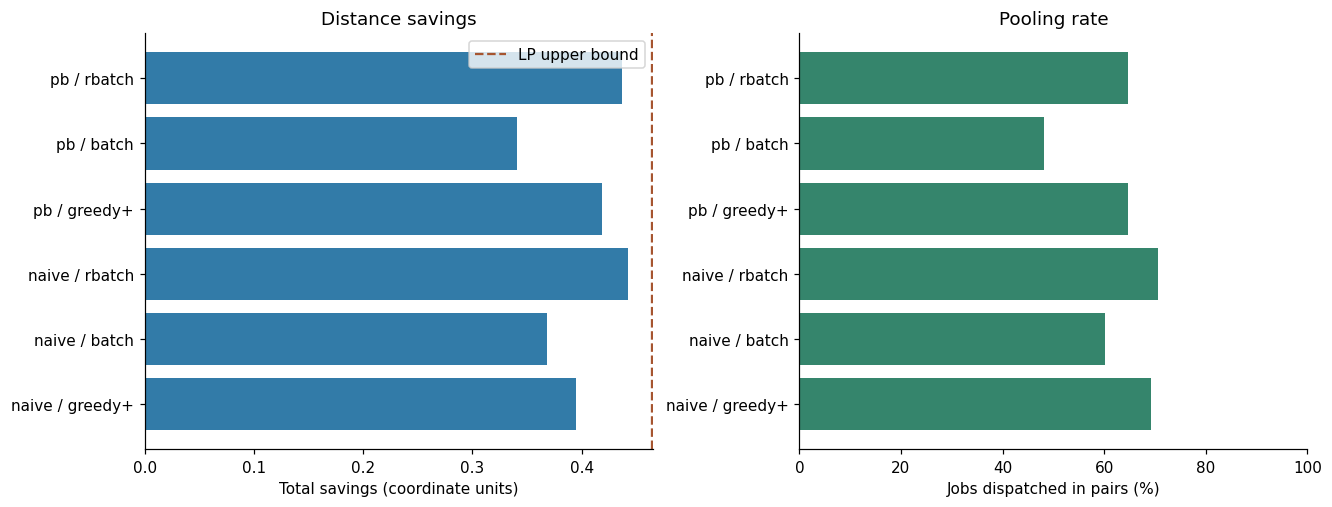

In [8]:
plot_frame = summary.copy()
labels = plot_frame.shadow + " / " + plot_frame.dispatch
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].barh(labels, plot_frame.savings, color="#327ba8")
axes[0].axvline(result["lp_total"], color="#a65530", linestyle="--", label="LP upper bound")
axes[0].set(xlabel="Total savings (coordinate units)", title="Distance savings")
axes[0].legend()
axes[1].barh(labels, plot_frame.pooled_pct, color="#35856c")
axes[1].set(xlabel="Jobs dispatched in pairs (%)", title="Pooling rate", xlim=(0, 100))
plt.show()

## Inspect selected pairs

Choose a shadow and dispatcher from the comparison above. These indices refer to
`job_frame`; `full_job_index` links each job back to the full loaded snapshot.
The displayed reward is the module's pooling reward, not the shadow-adjusted
matching weight. All pairs and solos are retained in `result["details"]`.
Use `INSPECT = "opt"` to inspect offline OPT when `with_opt=True`.

In [9]:
INSPECT = (RUN["shadows"][0], RUN["dispatches"][0])  # Example: ("pb", "rbatch")
detail = result["details"][INSPECT]
pooling_reward = make_reward_fn("pooling")
pair_frame = pd.DataFrame([
    dict(job_i=i, job_j=j,
         full_job_i=int(selected_indices[i]), full_job_j=int(selected_indices[j]),
         arrival_i_s=jobs[i].timestamp, arrival_j_s=jobs[j].timestamp,
         savings=pooling_reward(i, j, jobs))
    for i, j in detail["pairs"]
], columns=["job_i", "job_j", "full_job_i", "full_job_j",
            "arrival_i_s", "arrival_j_s", "savings"])
print(f"{INSPECT}: {len(pair_frame)} pairs, {len(detail['solos'])} solos")
display(pair_frame.head(15))

('naive', 'greedy+'): 46 pairs, 41 solos


,job_i,job_j,full_job_i,full_job_j,arrival_i_s,arrival_j_s,savings
0,1,45,1,45,0.0,43.0,0.001015
1,2,59,2,59,3.0,54.0,0.015660
2,3,52,3,52,4.0,48.0,0.003930
3,4,31,4,31,5.0,33.0,0.012021
4,5,11,5,11,5.0,12.0,0.007463
5,6,71,6,71,5.0,63.0,0.017871
6,7,50,7,50,6.0,46.0,0.009771
7,9,19,9,19,10.0,21.0,0.005464
8,10,44,10,44,11.0,43.0,0.010620
9,12,81,12,81,14.0,73.0,0.005548


## Optional parameter sweep

Set `RUN_SWEEP=True` to compare windows and gammas on exactly the same selected
jobs. Adjust shadows, algorithms, and other parameters through `SWEEP_BASE`.
The sweep sets `gamma` and `gamma_plus` to the candidate value so that batch+ and
rbatch+ respond to the gamma axis too; the results record which parameter each
policy actually used. This grid varies `d` and gamma; the other settings stay fixed.

For a fixed window use `D_VALUES=[60]`. For the full gamma grid use
`GAMMA_VALUES=np.round(np.arange(0, 1.01, 0.1), 1).tolist()`.
One point completes before the next starts. `sweep_rows` retains completed points
in memory if you interrupt a later one. Maxima here are **in-sample**, for this slice.

In [10]:
RUN_SWEEP = False
D_VALUES = [30.0, 60.0]
GAMMA_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
SWEEP_BASE = {**RUN, "shadows": ["pb"], "dispatches": ["rbatch"]}

sweep_rows = []
sweep_runs = []
if RUN_SWEEP:
    total = len(D_VALUES) * len(GAMMA_VALUES)
    for k, (d, gamma) in enumerate(((d, g) for d in D_VALUES for g in GAMMA_VALUES), 1):
        print(f"[{k}/{total}] d={d:g}s, gamma={gamma:g}", flush=True)
        trial = run_experiment(**{**SWEEP_BASE, "d": d, "gamma": gamma,
                                  "gamma_plus": gamma, "print_table": False})
        rows = trial["summary"].assign(sweep_gamma=gamma, evaluation_wall_s=trial["wall_time_s"])
        sweep_rows.extend(rows.to_dict("records"))
        sweep_runs.append({key: trial[key] for key in
                           ("settings", "source", "ad_source", "lp_time", "opt_time", "wall_time_s")})
else:
    print("Sweep disabled. Set RUN_SWEEP=True to run it.")
sweep_summary = pd.DataFrame(sweep_rows)

Sweep disabled. Set RUN_SWEEP=True to run it.


In [11]:
# Rebuild from completed rows, also useful after interrupting the sweep cell.
sweep_summary = pd.DataFrame(sweep_rows)
if not sweep_summary.empty:
    display(sweep_summary.sort_values(["d", "shadow", "dispatch", "sweep_gamma"]))
    candidates = sweep_summary[sweep_summary.shadow != "opt"]
    best = (candidates.sort_values(["savings", "sweep_gamma"], ascending=[False, True])
            .drop_duplicates(["d", "shadow", "dispatch"])
            .sort_values(["d", "shadow", "dispatch"]))
    print("Best tested gamma per window/shadow/dispatcher (smaller gamma breaks exact ties):")
    display(best[["d", "shadow", "dispatch", "sweep_gamma", "savings", "pooled_pct", "ratio_lp"]])
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    for (d, shadow, dispatch), group in candidates.groupby(["d", "shadow", "dispatch"]):
        group = group.sort_values("sweep_gamma")
        ax.plot(group.sweep_gamma, group.savings, marker="o",
                label=f"d={d:g}s · {shadow}/{dispatch}")
    ax.set(xlabel="Gamma candidate", ylabel="Total savings (coordinate units)",
           title="In-sample sensitivity on the selected jobs")
    ax.legend(fontsize=8)
    plt.show()

## Optional export

Set `SAVE_RESULTS=True` to save the single comparison, any completed sweep points,
the selected job ordering, pair/solo assignments, and settings/source hashes into
a new timestamped directory under `results/meituan_notebook/`. Original data and
GRID result files are not changed. The notebook's displayed output can also be
saved normally in Jupyter.

In [12]:
SAVE_RESULTS = False
if SAVE_RESULTS:
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    export_dir = ROOT / "results" / "meituan_notebook" / stamp
    export_dir.mkdir(parents=True, exist_ok=False)
    result["summary"].to_csv(export_dir / "comparison.csv", index=False)
    job_frame.to_csv(export_dir / "selected_jobs.csv", index=False)
    completed_sweep = pd.DataFrame(sweep_rows)
    if not completed_sweep.empty:
        completed_sweep.to_csv(export_dir / "sweep.csv", index=False)
    assignments = []
    for key, detail in result["details"].items():
        sh, disp = ("opt", "opt") if key == "opt" else key
        assignments.append(dict(shadow=sh, dispatch=disp, **detail))
    (export_dir / "matches.json").write_text(json.dumps(assignments, indent=2))
    metadata = dict(
        source=result["source"], single_run_settings=result["settings"],
        ad_source=result["ad_source"], lp_upper=result["lp_total"],
        opt_total=result["opt_total"], lp_time_s=result["lp_time"],
        opt_time_s=result["opt_time"], wall_time_s=result["wall_time_s"],
        completed_sweep_runs=sweep_runs,
        python=sys.version, ddp_module=str(ddp.__file__),
    )
    (export_dir / "settings.json").write_text(json.dumps(metadata, indent=2))
    print("Saved:", export_dir)
else:
    print("Export disabled. Set SAVE_RESULTS=True to save these experiments.")

Export disabled. Set SAVE_RESULTS=True to save these experiments.


## Modules used

- `ddp.scripts.csv_loader.load_jobs_from_csv`: parse and order the Meituan jobs.
- `ddp.scripts.run.run_instance`: evaluate the requested shadow × dispatch grid.
- `ddp.scripts.run.load_average_duals`: load precomputed historical values.
- `ddp.engine.sim.simulate`: underlying event-driven dispatch engine.
- `ddp.engine.opt`: fractional LP/duals and optional integral OPT.
- `ddp.model.reward` and `ddp.algorithms.potential`: pooling reward and PB base.

The lower-level `simulate` API also accepts a job-aligned shadow vector for custom
experiments. This notebook exposes the shadow families supported by `run_instance`;
it does not fit Area ID coefficients or generate historical AD tables.